## Análisis Exploratorio de Datos - Análisis Multivariable

### By:
Rafael Garcia

### Date:
2026-08-20

### Description:

Este notebook corresponde a la **Tarea 3: Análisis Exploratorio de Datos (EDA)** del Proyecto 1 del curso de MLOps.

En esta tercera parte se realiza el **análisis multivariable**, estudiando relaciones entre múltiples variables simultáneamente, identificando transformaciones necesarias y evaluando la viabilidad de un modelo heurístico.

## 📚 Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

## 💾 Load data

In [2]:
df = pd.read_parquet("../../data/02_intermediate/boston_housing_clean.parquet")

TARGET = "medv"
ID_COL = "ID"
NUMERIC_COLS = [
    "crim",
    "zn",
    "indus",
    "nox",
    "rm",
    "age",
    "dis",
    "tax",
    "ptratio",
    "black",
    "lstat",
]

print(f"Dimensiones: {df.shape}")

Dimensiones: (448, 15)


## 🔍 Análisis Multivariable

### Matriz de correlación completa

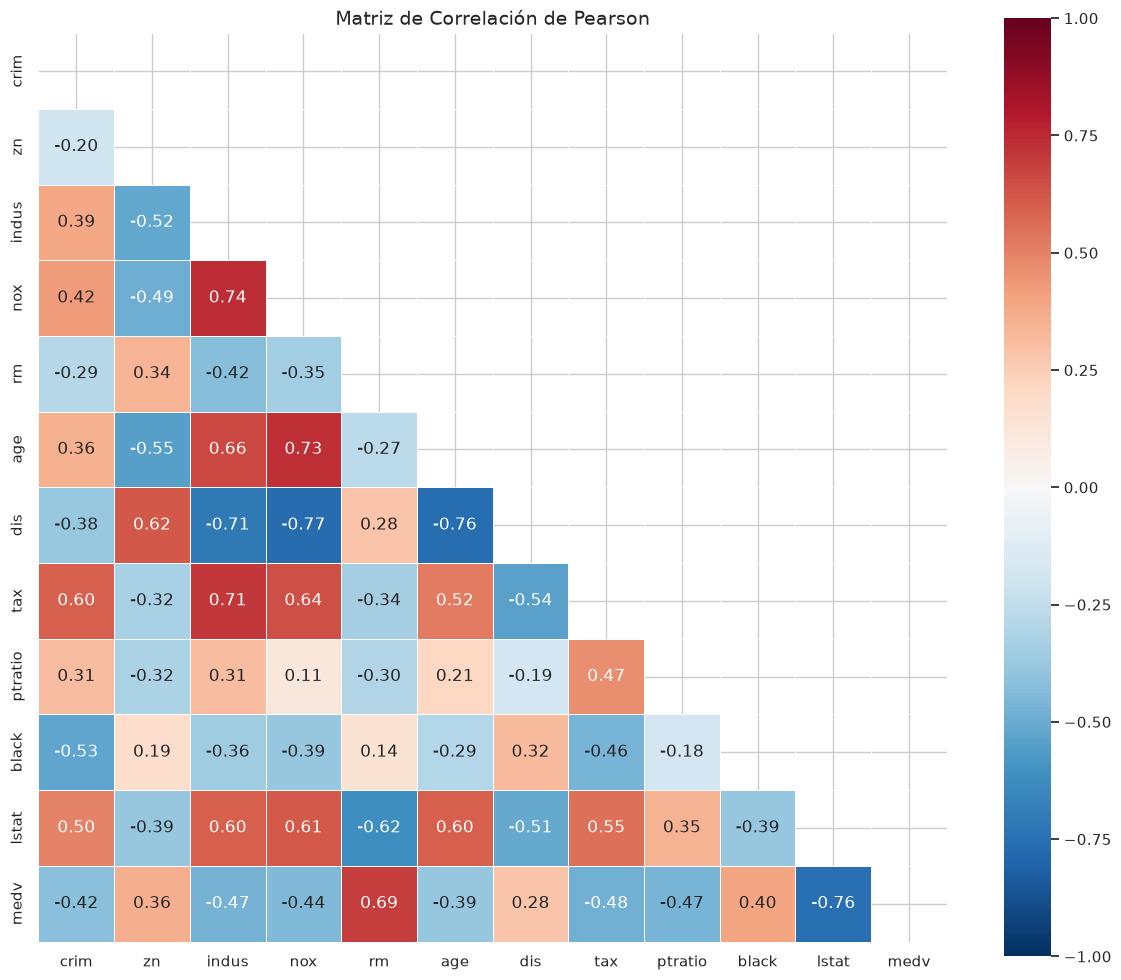

In [3]:
# Matriz de correlación
all_numeric = [*NUMERIC_COLS, TARGET]
corr_matrix = df[all_numeric].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Matriz de Correlación de Pearson", fontsize=14)
plt.tight_layout()
plt.show()

### Pairplot de las variables más relevantes

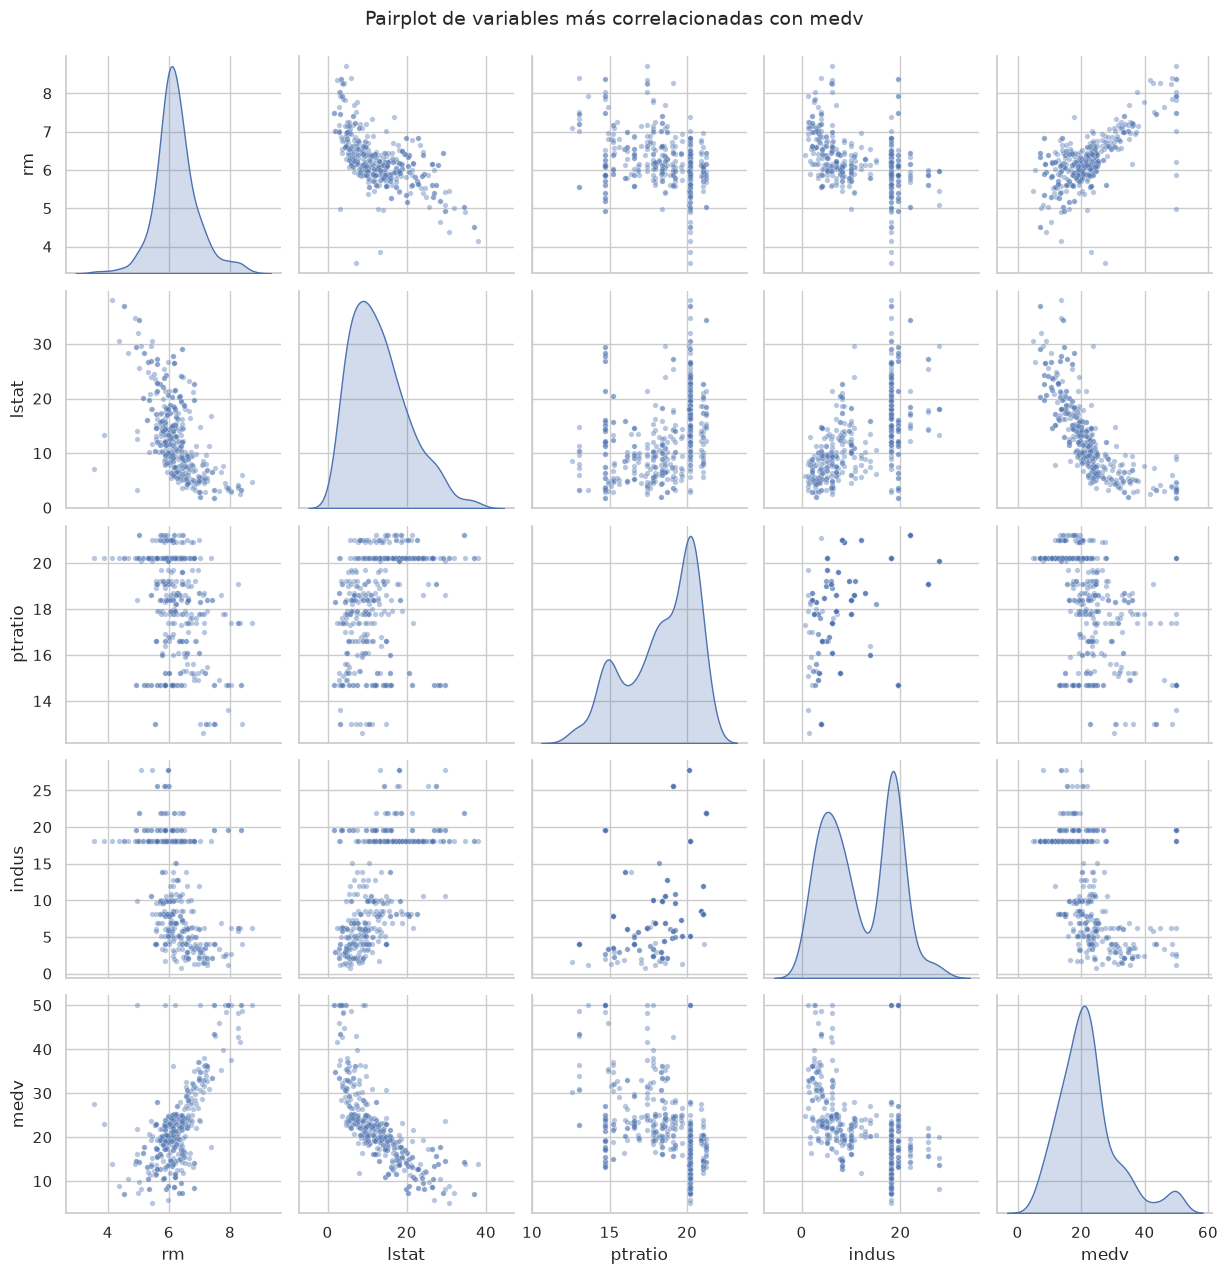

In [4]:
# Pairplot con las variables más correlacionadas con medv
TOP_VARS = ["rm", "lstat", "ptratio", "indus", TARGET]
g = sns.pairplot(df[TOP_VARS].dropna(), diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g.figure.suptitle("Pairplot de variables más correlacionadas con medv", y=1.02, fontsize=14)
plt.show()

### Análisis de multicolinealidad

In [5]:
# Grupos de variables altamente correlacionadas
HIGH_CORR_THRESHOLD = 0.7

print("=== Grupos de multicolinealidad ===")
print(f"Umbral: |r| > {HIGH_CORR_THRESHOLD}\n")

predictor_corr = df[NUMERIC_COLS].corr()
seen = set()
groups = []

for i in range(len(NUMERIC_COLS)):
    for j in range(i + 1, len(NUMERIC_COLS)):
        if abs(predictor_corr.iloc[i, j]) > HIGH_CORR_THRESHOLD:
            col1, col2 = NUMERIC_COLS[i], NUMERIC_COLS[j]
            corr_val = predictor_corr.iloc[i, j]
            print(f"  {col1} <-> {col2}: r = {corr_val:.4f}")
            groups.append((col1, col2, corr_val))

if not groups:
    print("  No se encontraron pares con correlación > 0.7")

print("\nImplicación: en modelos lineales, considerar eliminar una variable")
print("de cada par o usar regularización (Ridge, Lasso, ElasticNet).")

=== Grupos de multicolinealidad ===
Umbral: |r| > 0.7

  indus <-> nox: r = 0.7383
  indus <-> dis: r = -0.7131
  indus <-> tax: r = 0.7074
  nox <-> age: r = 0.7283
  nox <-> dis: r = -0.7678
  age <-> dis: r = -0.7624

Implicación: en modelos lineales, considerar eliminar una variable
de cada par o usar regularización (Ridge, Lasso, ElasticNet).


### Análisis con variable categórica `chas`

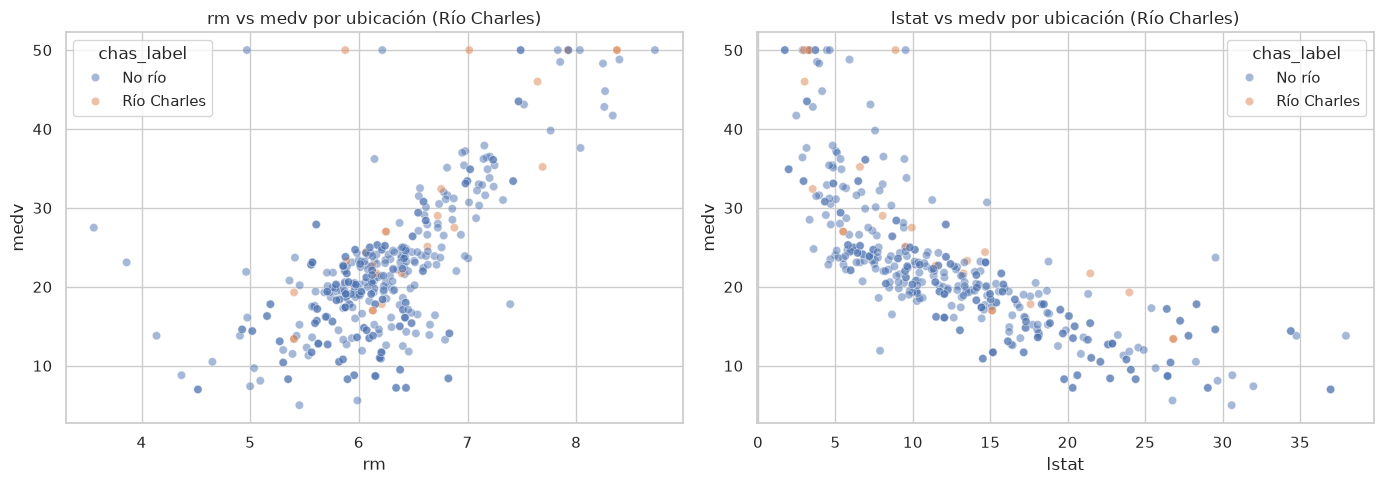

In [6]:
# Scatter de rm vs medv coloreado por chas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df[["rm", "lstat", "chas", TARGET]].dropna()
df_plot["chas_label"] = df_plot["chas"].map({0: "No río", 1: "Río Charles"})

sns.scatterplot(data=df_plot, x="rm", y=TARGET, hue="chas_label", alpha=0.5, ax=axes[0])
axes[0].set_title("rm vs medv por ubicación (Río Charles)")

sns.scatterplot(data=df_plot, x="lstat", y=TARGET, hue="chas_label", alpha=0.5, ax=axes[1])
axes[1].set_title("lstat vs medv por ubicación (Río Charles)")

plt.tight_layout()
plt.show()

### Segmentación por rangos de precio

In [7]:
# Crear segmentos de precio para análisis
PRICE_BINS = [0, 15, 25, 35, 51]
PRICE_LABELS = ["Bajo (<15k)", "Medio (15-25k)", "Alto (25-35k)", "Premium (>35k)"]

df_seg = df.dropna(subset=[TARGET]).copy()
df_seg["precio_seg"] = pd.cut(df_seg[TARGET], bins=PRICE_BINS, labels=PRICE_LABELS)

# Estadísticas por segmento
seg_stats = df_seg.groupby("precio_seg", observed=True)[NUMERIC_COLS].mean().round(4)
print("=== Promedio de variables por segmento de precio ===")
seg_stats

=== Promedio de variables por segmento de precio ===


,crim,zn,indus,nox,rm,age,dis,tax,ptratio,black,lstat
precio_seg,,,,,,,,,,,
Bajo (<15k),12.6141,0.2747,17.2857,0.6797,5.8250,94.1857,2.1696,586.6087,19.7370,249.0279,22.6709
Medio (15-25k),1.8619,6.4979,12.1401,0.5592,6.0658,68.7237,3.7226,396.7406,18.4324,369.8578,12.6037
Alto (25-35k),0.6735,28.1441,5.6992,0.4824,6.6867,48.1638,4.5757,307.8644,17.2828,385.8103,6.5366
Premium (>35k),1.1645,18.6667,7.6167,0.5227,7.4718,65.2077,3.5787,318.8974,16.3897,386.1179,4.7115


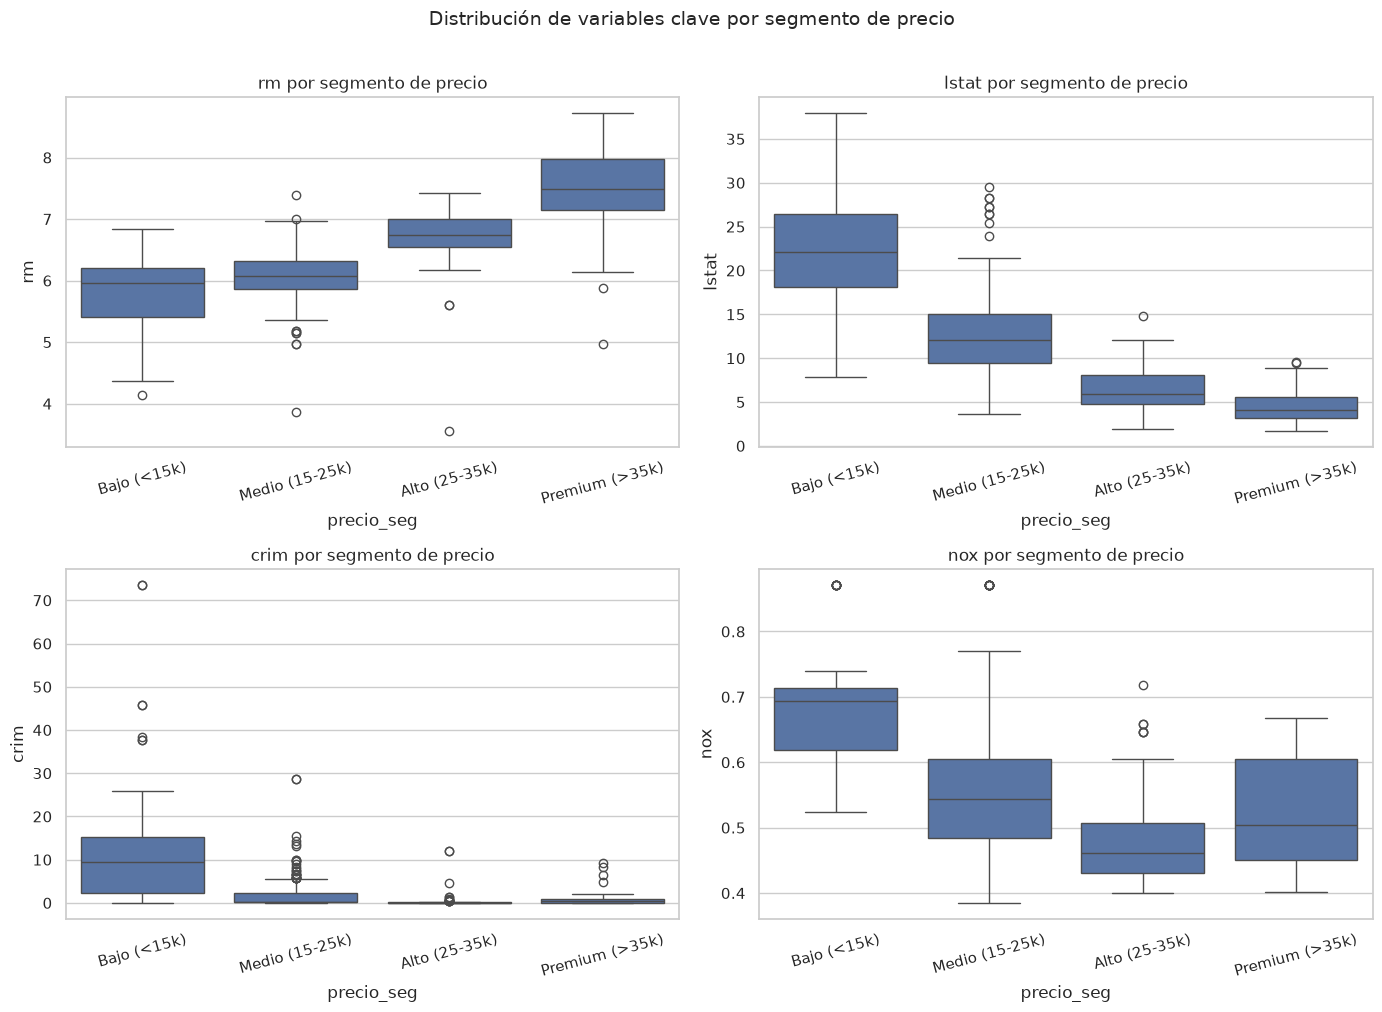

In [8]:
# Visualización de variables clave por segmento
KEY_VARS = ["rm", "lstat", "crim", "nox"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(KEY_VARS):
    sns.boxplot(data=df_seg, x="precio_seg", y=col, ax=axes[i])
    axes[i].set_title(f"{col} por segmento de precio")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Distribución de variables clave por segmento de precio", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Identificación de transformaciones

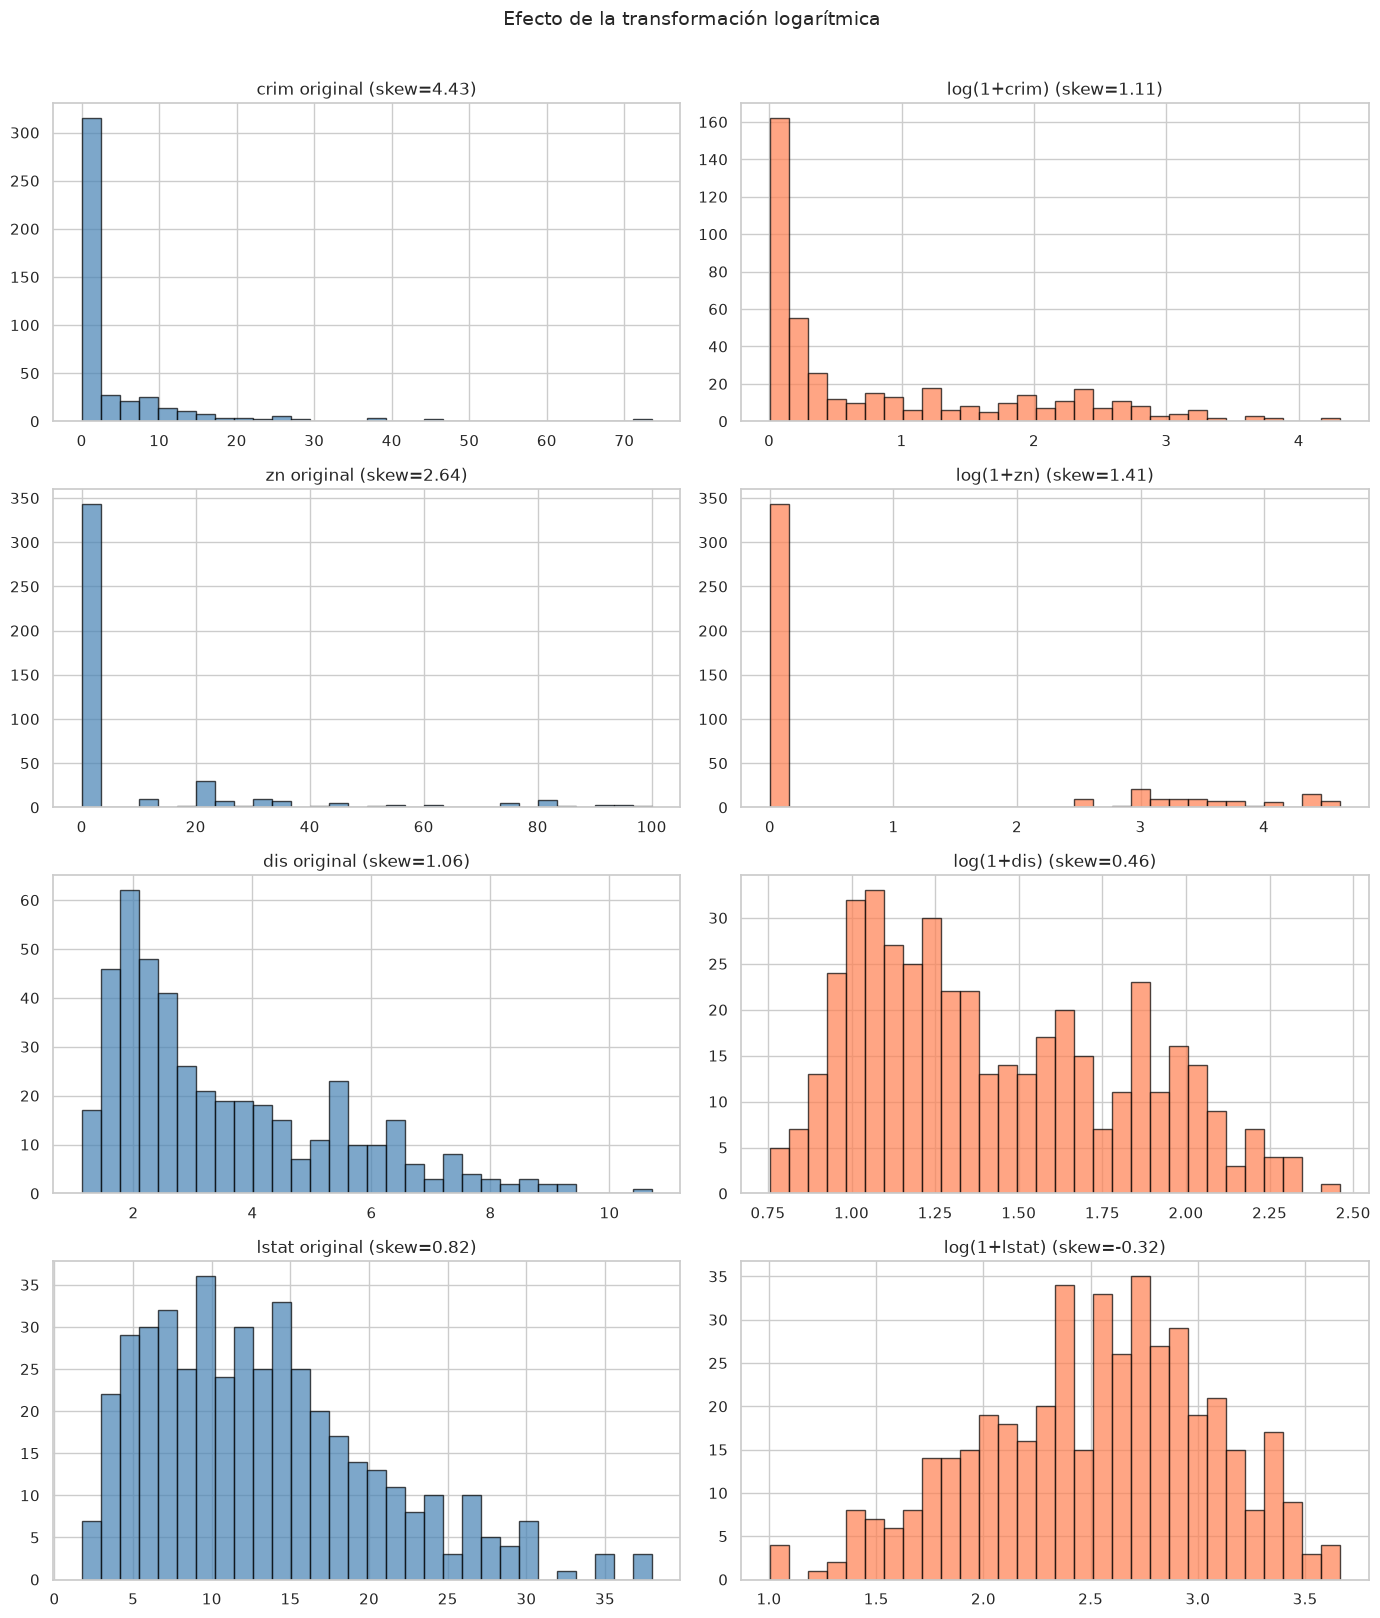

In [9]:
# Evaluar efecto de transformación log en variables sesgadas
SKEWED_VARS = ["crim", "zn", "dis", "lstat"]

fig, axes = plt.subplots(len(SKEWED_VARS), 2, figsize=(14, 4 * len(SKEWED_VARS)))

for i, col in enumerate(SKEWED_VARS):
    data = df[col].dropna()

    # Original
    axes[i, 0].hist(data, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    axes[i, 0].set_title(f"{col} original (skew={data.skew():.2f})")

    # Log transformado
    log_data = np.log1p(data)
    axes[i, 1].hist(log_data, bins=30, edgecolor="black", alpha=0.7, color="coral")
    axes[i, 1].set_title(f"log(1+{col}) (skew={log_data.skew():.2f})")

plt.suptitle("Efecto de la transformación logarítmica", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Resumen de transformaciones sugeridas
print("=== Transformaciones sugeridas para Feature Engineering ===")
print()
IMPROVEMENT_THRESHOLD = 0.5

for col in SKEWED_VARS:
    data = df[col].dropna()
    original_skew = data.skew()
    log_skew = np.log1p(data).skew()
    improvement = abs(original_skew) - abs(log_skew)
    recommended = (
        "✅ Recomendada"
        if improvement > IMPROVEMENT_THRESHOLD
        else "⚠️ Evaluar"
        if improvement > 0
        else "❌ No mejora"
    )
    print(f"  {col}: skew {original_skew:.2f} -> {log_skew:.2f} ({recommended})")

=== Transformaciones sugeridas para Feature Engineering ===

  crim: skew 4.43 -> 1.11 (✅ Recomendada)
  zn: skew 2.64 -> 1.41 (✅ Recomendada)
  dis: skew 1.06 -> 0.46 (✅ Recomendada)
  lstat: skew 0.82 -> -0.32 (⚠️ Evaluar)


### Modelo heurístico simple

Se evalúa si es viable un modelo simple basado en reglas manuales para tener como referencia.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelo heurístico: regresión lineal simple con rm (variable más intuitiva)
df_model = df[["rm", "lstat", TARGET]].dropna()

# Heurística: medv ≈ precio_base + coef_rm * rm + coef_lstat * lstat
# Estimamos coeficientes con la mediana como referencia
median_price = df_model[TARGET].median()
median_rm = df_model["rm"].median()
median_lstat = df_model["lstat"].median()

# Coeficientes simples basados en correlación
COEF_RM = 5.0  # Cada habitación adicional ≈ +$5,000
COEF_LSTAT = -0.5  # Cada punto de lstat ≈ -$500
intercept = median_price - COEF_RM * median_rm - COEF_LSTAT * median_lstat

# Predicción heurística
y_true = df_model[TARGET]
y_pred_heuristic = intercept + COEF_RM * df_model["rm"] + COEF_LSTAT * df_model["lstat"]

# Métricas
rmse_h = np.sqrt(mean_squared_error(y_true, y_pred_heuristic))
mae_h = mean_absolute_error(y_true, y_pred_heuristic)
r2_h = r2_score(y_true, y_pred_heuristic)

# Baseline: predecir siempre la media
y_pred_mean = np.full_like(y_true, y_true.mean())
rmse_mean = np.sqrt(mean_squared_error(y_true, y_pred_mean))
mae_mean = mean_absolute_error(y_true, y_pred_mean)

print("=== Evaluación del modelo heurístico ===")
print(f"\nRegla: medv = {intercept:.2f} + {COEF_RM} * rm + ({COEF_LSTAT}) * lstat")
print(f"\n{'Métrica':<10} {'Heurístico':>12} {'Baseline (media)':>18}")
print("-" * 42)
print(f"{'RMSE':<10} {rmse_h:>12.4f} {rmse_mean:>18.4f}")
print(f"{'MAE':<10} {mae_h:>12.4f} {mae_mean:>18.4f}")
print(f"{'R²':<10} {r2_h:>12.4f} {'0.0000':>18}")
print(f"\nEl modelo heurístico {'SÍ' if rmse_h < rmse_mean else 'NO'} supera al baseline.")

=== Evaluación del modelo heurístico ===

Regla: medv = -4.14 + 5.0 * rm + (-0.5) * lstat

Métrica      Heurístico   Baseline (media)
------------------------------------------
RMSE             5.8206             9.2198
MAE              3.9545             6.6738
R²               0.6014             0.0000

El modelo heurístico SÍ supera al baseline.


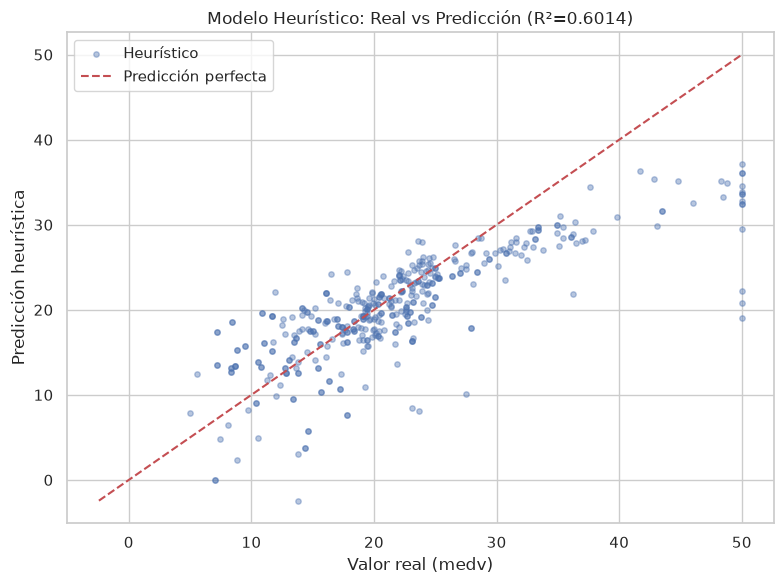

In [12]:
# Gráfico de predicción vs real
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_true, y_pred_heuristic, alpha=0.4, s=15, label="Heurístico")
lim_min = min(y_true.min(), y_pred_heuristic.min())
lim_max = max(y_true.max(), y_pred_heuristic.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", label="Predicción perfecta")
ax.set_xlabel("Valor real (medv)")
ax.set_ylabel("Predicción heurística")
ax.set_title(f"Modelo Heurístico: Real vs Predicción (R²={r2_h:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

### Datos adicionales que podrían ser útiles

In [13]:
print("=== Datos adicionales que podrían mejorar el modelo ===")
print()
print("1. Tamaño del lote (sq.ft) - dato directo de la propiedad")
print("2. Año de construcción - más preciso que 'age' (proporción antes de 1940)")
print("3. Número de baños - complementa a 'rm'")
print("4. Estado de la propiedad / renovaciones recientes")
print("5. Distancia a transporte público (más granular que 'rad')")
print("6. Datos de ventas recientes en la zona (comparables)")
print("7. Índice de calidad de escuelas (más preciso que 'ptratio')")
print("8. Datos geoespaciales (coordenadas, cercanía a amenidades)")

=== Datos adicionales que podrían mejorar el modelo ===

1. Tamaño del lote (sq.ft) - dato directo de la propiedad
2. Año de construcción - más preciso que 'age' (proporción antes de 1940)
3. Número de baños - complementa a 'rm'
4. Estado de la propiedad / renovaciones recientes
5. Distancia a transporte público (más granular que 'rad')
6. Datos de ventas recientes en la zona (comparables)
7. Índice de calidad de escuelas (más preciso que 'ptratio')
8. Datos geoespaciales (coordenadas, cercanía a amenidades)


## 📊 Analysis of Results and Conclusions

### Resultados del análisis multivariable

1. **Matriz de correlación**: confirma que `lstat` y `rm` son los predictores más fuertes. Se detectaron grupos de variables correlacionadas entre sí (multicolinealidad) que deben manejarse.

2. **Segmentación por precio**: las viviendas premium (>35k) se caracterizan por más habitaciones, menor lstat, menor criminalidad y menor contaminación (nox). Los patrones son consistentes y predecibles.

3. **Transformaciones**: la transformación logarítmica reduce significativamente la asimetría en `crim`, `dis` y `lstat`. Se recomienda aplicarla en el feature engineering.

4. **Modelo heurístico**: un modelo simple basado en `rm` y `lstat` con coeficientes manuales ya supera al baseline de predecir la media. Esto confirma que el problema es abordable con ML y que estas dos variables capturan información relevante.

### ¿Es viable un modelo heurístico?

Sí, un modelo heurístico simple es viable como baseline. Sin embargo, su rendimiento es limitado por no capturar relaciones no lineales ni interacciones entre variables. Un modelo de ML debería mejorar sustancialmente estos resultados.

### Conclusiones generales del EDA

- Las variables `lstat`, `rm`, `ptratio`, `indus` y `tax` son las más relevantes para el modelo.
- Se requieren transformaciones logarítmicas para varias variables.
- La multicolinealidad sugiere usar regularización o modelos basados en árboles.
- El modelo heurístico establece un piso de rendimiento que el modelo ML debe superar.
- La variable `black` debe evaluarse éticamente antes de incluirla.

## 💡 Proposals and Ideas

1. **Feature Engineering (Tarea 4)**: aplicar log a `crim`, `lstat`, `dis`. Crear interacciones `rm²`, `rm * lstat`. Binarizar `zn`.
2. **Modelo Baseline (Tarea 5)**: usar el modelo heurístico documentado aquí como referencia.
3. **Selección de modelos (Tarea 6)**: probar Random Forest, Gradient Boosting (XGBoost/LightGBM), Ridge y ElasticNet.
4. **Variable ética**: documentar la decisión sobre `black` y considerar excluirla.
5. **Censura en medv=50**: evaluar si eliminar o mantener los registros con medv=50.

##  References

- Guía del proyecto (Tarea 3): [joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/)
- Scikit-learn metrics: [sklearn.metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)
- Harrison, D. and Rubinfeld, D.L. (1978). *Hedonic housing prices and the demand for clean air*.